<a href="https://colab.research.google.com/github/Johnal96/ITAI2373-NewsBot-Midterm/blob/main/itai2373_newsbot_midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np

In [30]:
import zipfile
import os

zip_path = '/content/learn-ai-bbc.zip'
extract_path = '/content/'

# Check if the zip file exists and extract its contents
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted contents of {zip_path} to {extract_path}")
else:
    print(f"Zip file not found at {zip_path}. Please ensure it is uploaded.")

df = pd.read_csv('/content/BBC News Train.csv')
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

Extracted contents of /content/learn-ai-bbc.zip to /content/
Dataset Info:
Shape: (1490, 3)
Columns: ['ArticleId', 'Text', 'Category']

First few rows:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


In [31]:
text_column = 'Text'  # or 'description', 'content', 'headline', etc.
category_column = 'Category'  # or 'label', 'class', etc.

In [32]:
print(f"\nMissing values:")
print(df.isnull().sum())


Missing values:
ArticleId    0
Text         0
Category     0
dtype: int64


In [33]:
df_clean = df.dropna(subset=[text_column, category_column])

In [34]:
print(f"\nCategory distribution:")
print(df_clean[category_column].value_counts())


Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [35]:
if len(df_clean) > 2000:
    df_final = df_clean.sample(n=2000, random_state=42)
    print(f"\nSampled dataset to {len(df_final)} rows")
else:
    df_final = df_clean

In [36]:
df_final = df_final.rename(columns={
    text_column: 'content',
    category_column: 'category'
})

In [37]:
df_final.to_csv('newsbot_dataset.csv', index=False)
print("\n✅ Dataset prepared and saved as 'newsbot_dataset.csv'")


✅ Dataset prepared and saved as 'newsbot_dataset.csv'


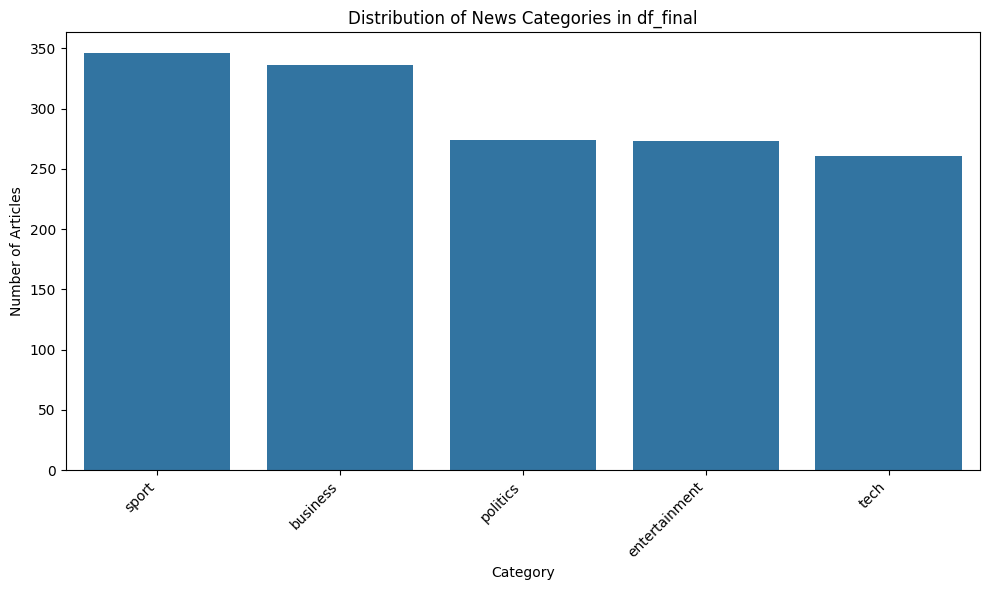

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='category', order=df_final['category'].value_counts().index)
plt.title('Distribution of News Categories in df_final')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()